 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : Tomas Wynne                <br>
Student Number : L00196526                  <br>
Due Date       : 17th May 2026              <br>
Assignment     : CA2                        <br>
Module         : AI for Vision and NLP      <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
![Workflow Image](Pipeline%20workflow.png)

# Initialisation

## Install packages

In [1]:
%pip install -r requirements.txt
!python -m spacy download en_core_web_sm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports

In [2]:
import os
import cv2
import pymupdf
import json
import pandas as pd
import numpy as np
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import pytesseract

## Variable Assignments

In [3]:
# Load NLP Spacy model
nlp = spacy.load("en_core_web_sm")

# Data files origin folder
DATA_FOLDER = "data"

# Results Save Location
OUTPUT_FOLDER = "results"
ANNOTATED_FOLDER = os.path.join(OUTPUT_FOLDER,"annotated_images")
os.makedirs(ANNOTATED_FOLDER, exist_ok=True)

# JSON output file
output_json="final_multimodal_results.json"

# Tesseract Path
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# OCR Config:
# 3 = Default, based on what is available 
# 6 = Assume a uniform block of text
ocr_config = r'--oem 3 --psm 6'


# Supported extensions
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png"]
PDF_EXTENSIONS = [".pdf"]

## Support Functions

In [4]:
# Used chatgpt to assist with laying out the file intake and document sorting after pivoting to taking all files in together rather than processing individually.

# Breaks pdfs down to an image per page, returns list of RGB images from the PDF
def pdf_to_images(pdf_path):
    doc = pymupdf.open(pdf_path)

    images = []

    filename = os.path.splitext(os.path.basename(pdf_path))[0]

    for page_number, page in enumerate(doc):
        # Convert page to image
        pix = page.get_pixmap(dpi=200)

        # Convert pixmap to numpy array
        img_data = np.frombuffer(
            pix.samples,
            dtype=np.uint8
        )

        image = img_data.reshape(
            pix.height,
            pix.width,
            pix.n
        )

        # Convert RGBA to RGB if needed
        if pix.n == 4:
            image = cv2.cvtColor(
                image,
                cv2.COLOR_RGBA2RGB
            )

        images.append({
            "page": page_number + 1,
            "image": image,
            "source": filename
        })

    return images


# Reads in an image and coverts it to RGB
def load_image(path):
    image = cv2.imread(path)
    if image is None:
        raise ValueError(f"Could not load image: {path}")
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image_rgb

# NLP

## NLP Functions

In [5]:
# Makes a token out of the lemma of every word in the document that is not a stop word, punctuation or a space
def preprocess_text(text):
    document = nlp(text)
    tokens = []

    for token in document:
        if not token.is_stop and not token.is_punct and not token.is_space:
            tokens.append(token.lemma_.lower())
    
    return tokens, document



# Returns Named Entities
def get_entities(document):

    entities = []
    for ent in document.ents:
        entities.append({
            "text": ent.text,
            "label": ent.label_
        })

    return entities



def get_tfidf(tokens, top_n=15):
    clean_text = " ".join(tokens)

    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform([clean_text])
    feature_names = vectorizer.get_feature_names_out()

    scores = tfidf_matrix.toarray()[0]
    features = list(zip(feature_names, scores))

    # Sort highest first
    features = sorted(features, key=lambda x: x[1], reverse=True)

    top_features = []

    for word, score in features[:top_n]:
        top_features.append({
            "word": word,
            "score": float(score)
        })

    return top_features



def extract_keyphrases(doc):
    return list(set([
        chunk.text.lower()
        for chunk in doc.noun_chunks
        if len(chunk.text.split()) > 1
    ]))

## Image Preprocessing

In [6]:
def preprocess_image(image):
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
    contrast_enhanced = clahe.apply(gray)

    # Noise reduction with blurring
    blur = cv2.GaussianBlur(gray,(5,5),0)

    # Adaptive thresholding
    thresh = cv2.adaptiveThreshold(blur,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY_INV,11,8)

    # Apply opening
    kernel = np.ones((2,2), np.uint8)
    opened = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel)

    return gray, blur, opened



def process_image(image, filename, page_number=1):
    print(f"\nProcessing: {filename} | Page: {page_number}")

    # Preprocess image
    gray, blur, opened = preprocess_image(image)

    # OCR
    text = pytesseract.image_to_string(opened, config=ocr_config)

    # NLP preprocessing
    tokens, document = preprocess_text(text)

    # Entities
    entities = get_entities(document)

    # TF-IDF
    keywords = get_tfidf(tokens)

    keyphrases = extract_keyphrases(document)

    # Store results
    result = {
        "filename": filename,
        "page": page_number,
        "raw_text": text,
        "clean_tokens": tokens,
        "named_entities": entities,
        "top_keywords": keywords,
        "key_phrases": keyphrases
    }

    return result, gray, blur, opened

## Document Processing

In [7]:
all_results = []

# Optional preview images
preview_images = []

# Loop through all files
for file in os.listdir(DATA_FOLDER):

    file_path = os.path.join(DATA_FOLDER, file)

    extension = os.path.splitext(file)[1].lower()

    # PDF Files
    if extension in PDF_EXTENSIONS:

        print(f"\nDetected PDF: {file}")
        pdf_images = pdf_to_images(file_path)

        for page_data in pdf_images:
            image = page_data["image"]

            result, gray, blur, opened = process_image(image,file,page_data["page"])

            all_results.append(result)

            preview_images.append({
                "filename": file,
                "page": page_data["page"],
                "original": image,
                "gray": gray,
                "blur": blur,
                "opened": opened
            })


    # Image Files
    elif extension in IMAGE_EXTENSIONS:

        print(f"\nDetected Image: {file}")

        image = load_image(file_path)

        result, gray, blur, opened = process_image(image,file,page_number=1)

        all_results.append(result)

        preview_images.append({
            "filename": file,
            "page": page_data["page"],
            "original": image,
            "gray": gray,
            "blur": blur,
            "opened": opened
        })


    else:
        print(f"Skipping unsupported file: {file}")


Detected PDF: BDA_CA2_Technical_Report.pdf

Processing: BDA_CA2_Technical_Report.pdf | Page: 1

Processing: BDA_CA2_Technical_Report.pdf | Page: 2

Processing: BDA_CA2_Technical_Report.pdf | Page: 3

Processing: BDA_CA2_Technical_Report.pdf | Page: 4

Processing: BDA_CA2_Technical_Report.pdf | Page: 5

Detected Image: Blue Prince Screenshot.png

Processing: Blue Prince Screenshot.png | Page: 1

Detected Image: Photo of a page.jpeg

Processing: Photo of a page.jpeg | Page: 1

Detected Image: Scanned Receipt.jpg

Processing: Scanned Receipt.jpg | Page: 1

Detected PDF: Using_Behavioural_Skills_Training_with_Healthcare_page_2.pdf

Processing: Using_Behavioural_Skills_Training_with_Healthcare_page_2.pdf | Page: 1


## NLP Results

In [8]:
print("\n\n================================================")
print("SAMPLE RESULTS")
print("================================================")

for result in all_results:

    print(f"\n\n\n\nFILE: {result['filename']}")
    print(f"PAGE: {result['page']}")

    print("\n--- RAW TEXT PREVIEW ---")
    print("------------------------")
    print(result["raw_text"][:500])

    print("\n--- TOP KEYWORDS ---")
    print("--------------------")
    for keyword in result["top_keywords"][:10]:
        print(f"{keyword['word']} : {keyword['score']:.4f}")

    print("\n--- NAMED ENTITIES ---")
    print("----------------------")
    for entity in result["named_entities"][:10]:
        print(f"{entity['text']} ({entity['label']})")

    print("\n--- KEY PHRASES ---")
    print("----------------------")
    for phrase in result["key_phrases"][:10]:
        print(phrase)



SAMPLE RESULTS




FILE: BDA_CA2_Technical_Report.pdf
PAGE: 1

--- RAW TEXT PREVIEW ---
------------------------
1
Predictive Analytics on Large-Scale NYC Taxi Trip
Data (January—June 2025)
Tomas Wynne
Computing Department, Atlantic Technological University (ATU)
L00196526 @atu.ie
Abstract
This report details the implementation of an end-to-end Big Data analytics pipeline to predict trip outcomes
for NYC Yellow Taxis using 24 million records from January-June 2025. Leveraging Apache Spark on Databricks,
we addressed three predictive tasks: duration regression, fare regression, and binary trip-length classi

--- TOP KEYWORDS ---
--------------------
trip : 0.3205
dataset : 0.2404
data : 0.2003
fare : 0.2003
duration : 0.1603
record : 0.1603
taxi : 0.1603
2025 : 0.1202
24 : 0.1202
base : 0.1202

--- NAMED ENTITIES ---
----------------------
1 (CARDINAL)
Predictive Analytics (ORG)
January—June 2025 (DATE)
Tomas Wynne (PERSON)
Atlantic Technological University (ORG)
Big Data (ORG)
24 mil

In [9]:
# Save to Dataframe
results_df = pd.DataFrame(all_results)

print("\n==========================")
print("DATAFRAME OVERVIEW")
print("==========================")

results_df


DATAFRAME OVERVIEW


,filename,page,raw_text,clean_tokens,named_entities,top_keywords,key_phrases
0,BDA_CA2_Technical_Report.pdf,1,1\nPredictive Analytics on Large-Scale NYC Tax...,"[1, predictive, analytics, large, scale, nyc, ...","[{'text': '1', 'label': 'CARDINAL'}, {'text': ...","[{'word': 'trip', 'score': 0.3205132320860016}...","[sourced data, key features, pickup timestamp,..."
1,BDA_CA2_Technical_Report.pdf,2,2\nand merged into one Dataframe. For explorat...,"[2, merge, dataframe, exploratory, vat, parque...","[{'text': '2', 'label': 'CARDINAL'}, {'text': ...","[{'word': 'trip', 'score': 0.4432422071779362}...","[daily demand cycles, spark rate modelling not..."
2,BDA_CA2_Technical_Report.pdf,3,3\ne Linear Regression (LR): This was selected...,"[3, e, linear, regression, lr, select, baselin...","[{'text': '3', 'label': 'CARDINAL'}, {'text': ...","[{'word': 'model', 'score': 0.3674234614174767...","[location-specific traffic density, its high i..."
3,BDA_CA2_Technical_Report.pdf,4,4\nIV. RESULTS AND ANALYSIS Residual Plot for ...,"[4, iv, results, analysis, residual, plot, tri...","[{'text': '4', 'label': 'CARDINAL'}, {'text': ...","[{'word': 'trip', 'score': 0.29095718698132317...","[the 0.690, 3. residual plot, a cleaner distri..."
4,BDA_CA2_Technical_Report.pdf,5,5\na REFERENCES\n- {l] N. Y. C. Taxi and L. Co...,"[5, references, l, n., y., c., taxi, l., commi...","[{'text': '5', 'label': 'CARDINAL'}, {'text': ...","[{'word': 'trip', 'score': 0.3584885719585767}...","[the random forest, a comparative analysis, th..."
5,Blue Prince Screenshot.png,1,/ \— + ee eee Renee\n7 THE SOIL SURVEY iL_| [|...,"[+, ee, eee, renee, 7, soil, survey, il_|, |, ...","[{'text': 'Renee', 'label': 'PERSON'}, {'text'...","[{'word': 'soil', 'score': 0.5132649025747366}...","[a such an undertaking, no way, the amount, th..."
6,Photo of a page.jpeg,1,a What is a “weird thing” in\nNOUR your home t...,"[weird, thing, nour, home, love, <, work, supe...","[{'text': 'NOUR', 'label': 'GPE'}, {'text': '1...","[{'word': 'bowl', 'score': 0.2879263002994778}...","[the\nroom, my socks, the dirty hand towels, t..."
7,Scanned Receipt.jpg,1,Tax Invoice\nFLORISM DE ART (940075-x)\nLOT 2....,"[tax, invoice, florism, de, art, 940075, x, lo...","[{'text': 'LOT 2.70.00', 'label': 'ORG'}, {'te...","[{'word': '00', 'score': 0.4435327625727437}, ...","[55100 kuala lumpur, amount tax, 03-2142 3855\..."
8,Using_Behavioural_Skills_Training_with_Healthc...,1,"Behav, Sci. 2025, 15, 870 Sof 21\nintervention...","[behav, sci, 2025, 15, 870, sof, 21, intervent...","[{'text': 'Behav', 'label': 'PERSON'}, {'text'...","[{'word': 'change', 'score': 0.289420488622949...","[all three partic-\nipants, 870 sof 21\ninterv..."


# Vision

## Computer Vision Functions

In [10]:
# Used chatgpt to assist with heuristic if/else parameters to classify regions as body text / tables / captions/ titles / etc

def classify_region(region, roi):

    x = region["x"]
    y = region["y"]
    w = region["w"]
    h = region["h"]

    area = region["area"]

    text = region["text"].strip()

    text_length = len(text)

    # Number of lines in OCR text
    line_count = len(text.splitlines())

    # Number of words
    word_count = len(text.split())

    # Aspect ratio
    aspect_ratio = w / h

    # Edge density
    edges = cv2.Canny(roi, 50, 150)

    edge_pixels = np.sum(edges > 0)

    edge_density = edge_pixels / area

    digit_count = sum(c.isdigit() for c in text)

    digit_ratio = digit_count / max(len(text), 1)
    
    '''
    # Code for testing regions
    print("\n======================")
    print(f"Label: {label}")
    print(f"Words: {word_count}")
    print(f"Lines: {line_count}")
    print(f"Aspect Ratio: {aspect_ratio:.2f}")
    print(f"Edge Density: {edge_density:.4f}")
    print(f"Digit Ratio: {digit_ratio:.4f}") 
    '''

    # TITLE DETECTION
    if (
        y < 250
        and word_count > 3
        and word_count < 20
        and line_count <= 3
        and aspect_ratio > 2
    ):
        return "Title"


    # CAPTION DETECTION
    elif (
        word_count < 15
        and line_count <= 2
        and area < 80000
        and y > 200
    ):
        return "Caption"


    # DIAGRAM / IMAGE DETECTION
    elif text_length < 40 and area > 100000:
        return "Diagram/Image"


    # TABLE DETECTION
    elif (
        line_count > 4
        and digit_ratio > 0.1
        and edge_density > 0.05
        ):
        return "Table"


    # DEFAULT TO BODY TEXT
    else:
        return "Body Text"

## Display Image Preprocessing 

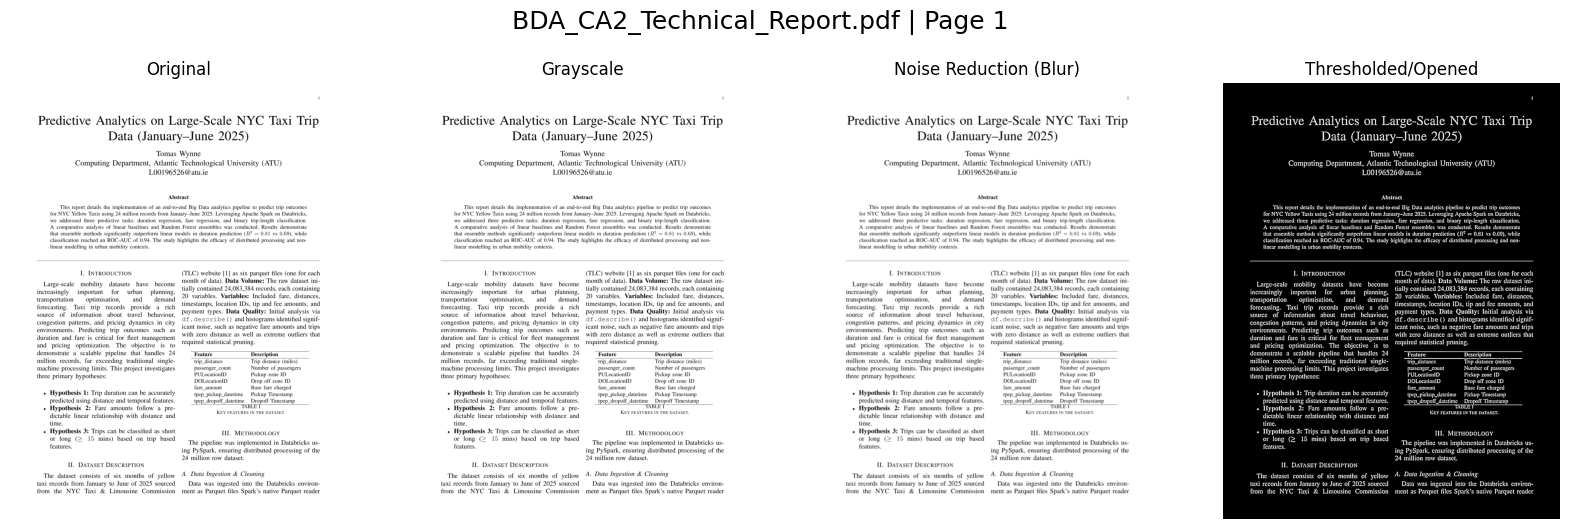

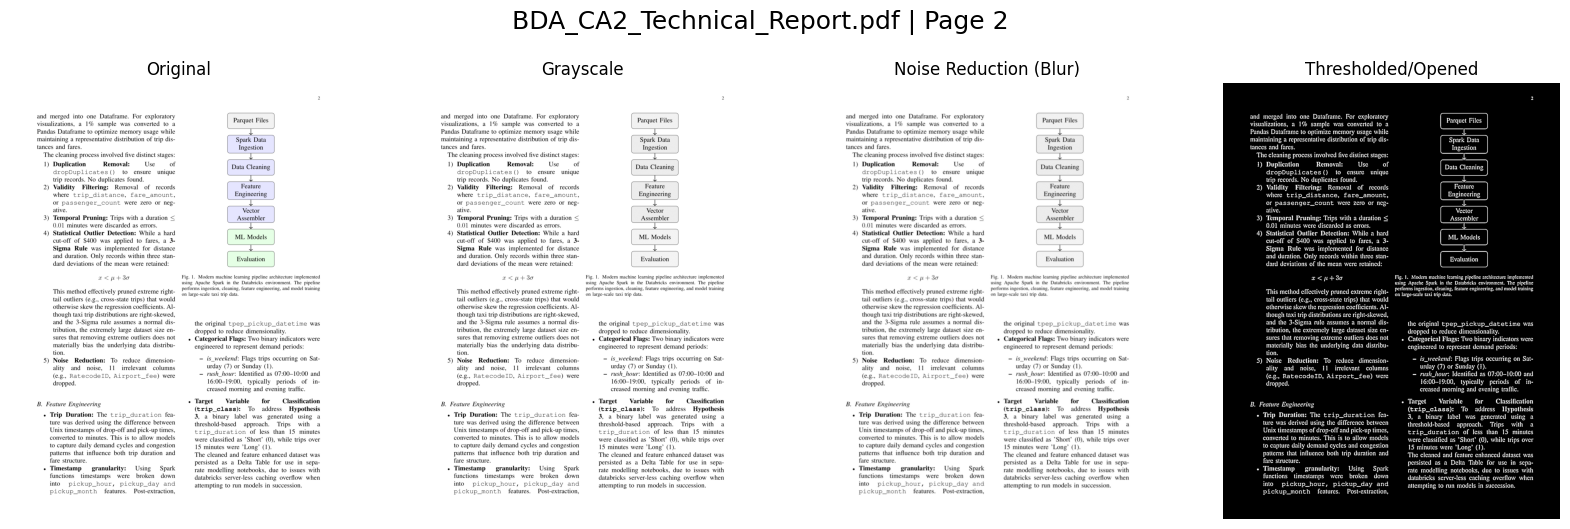

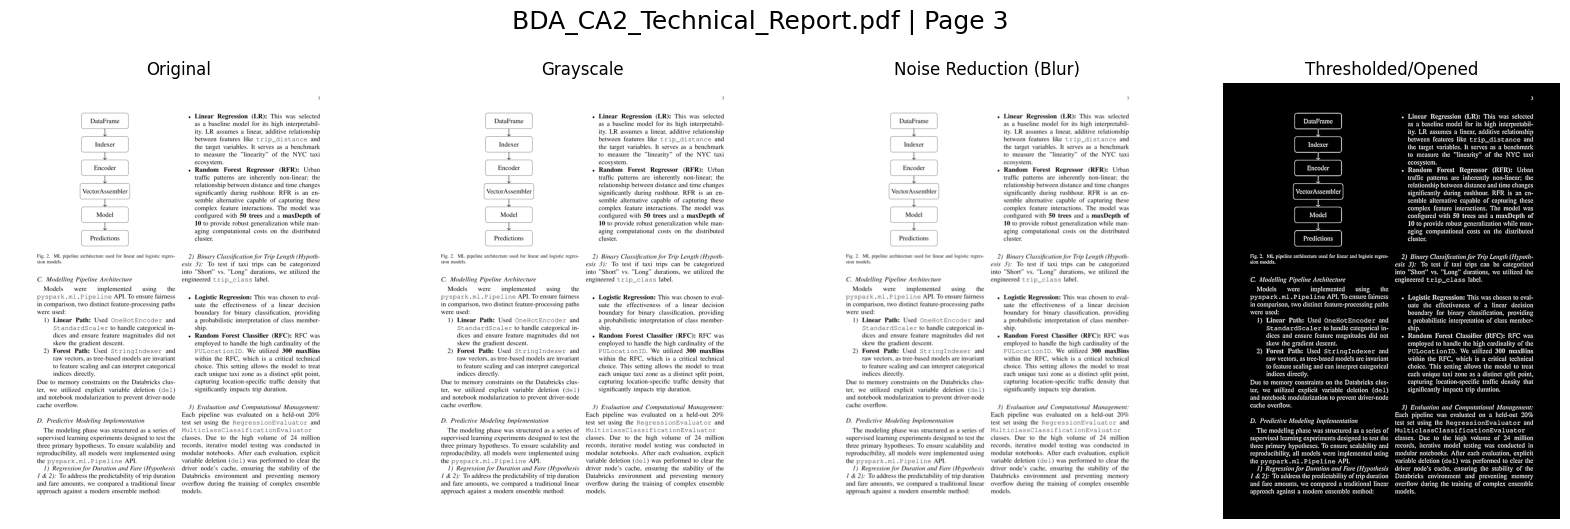

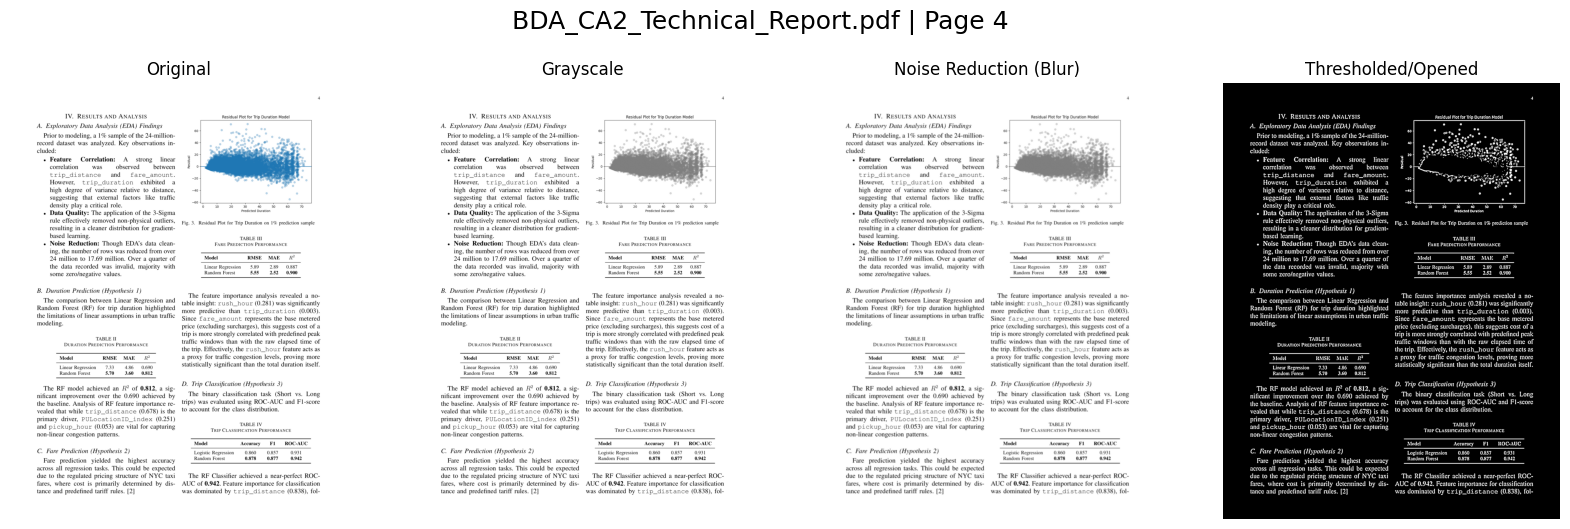

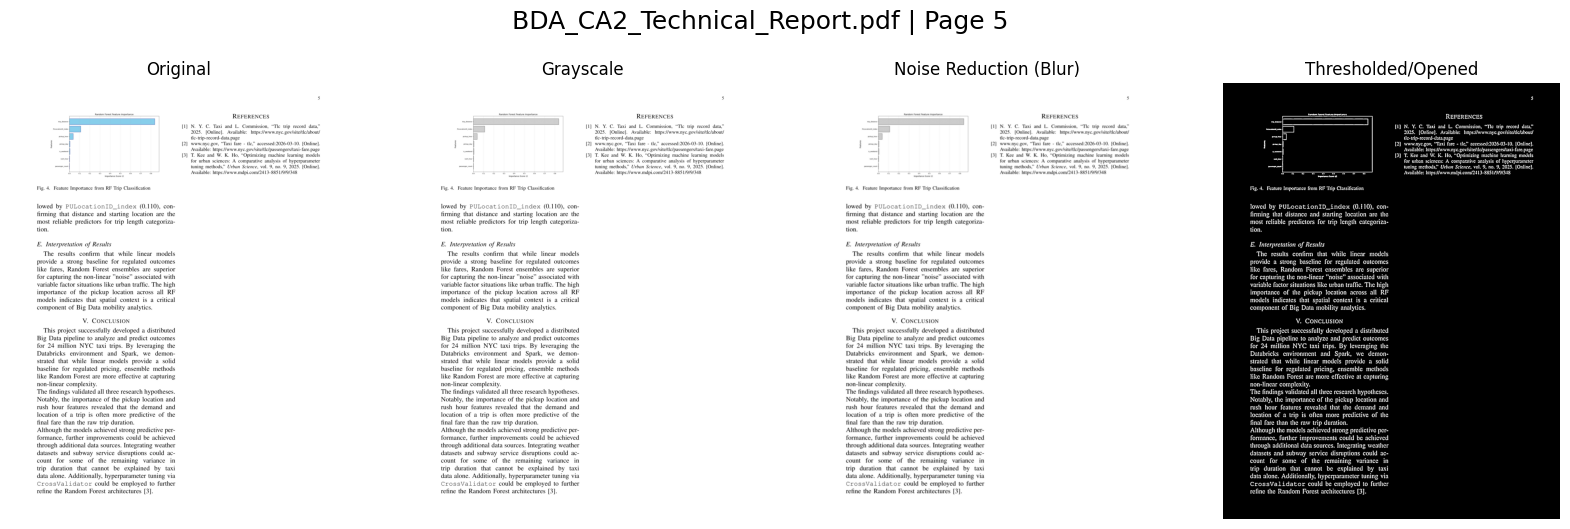

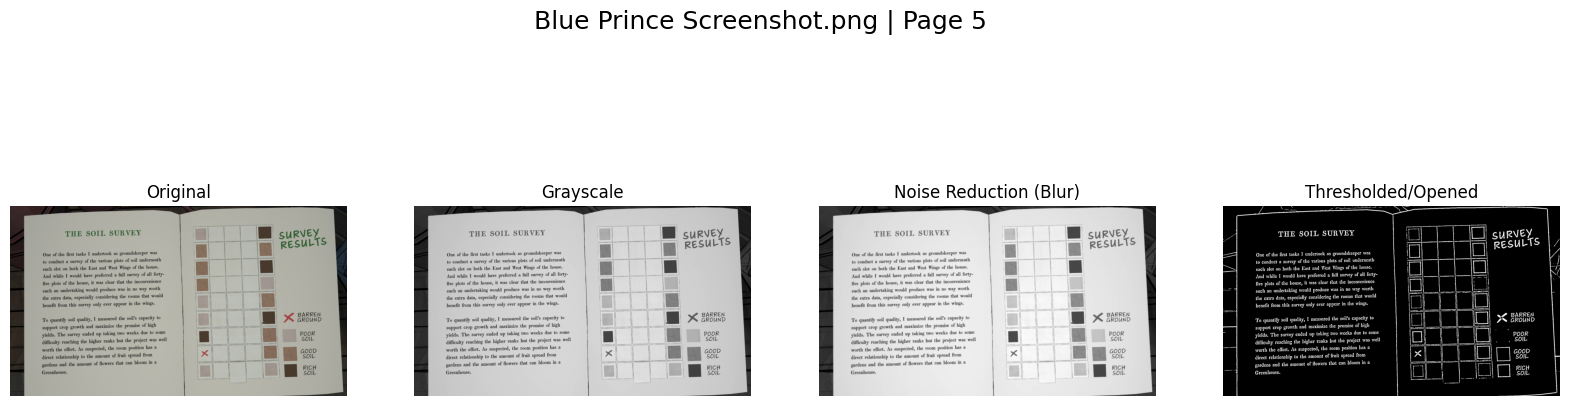

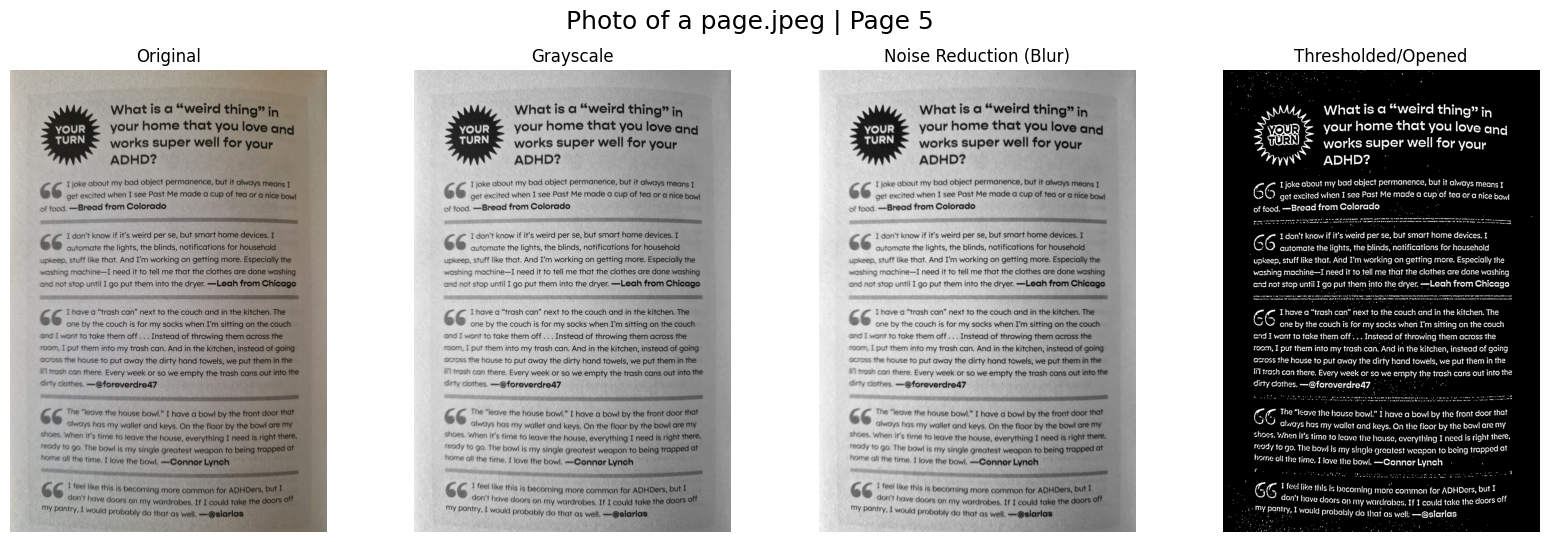

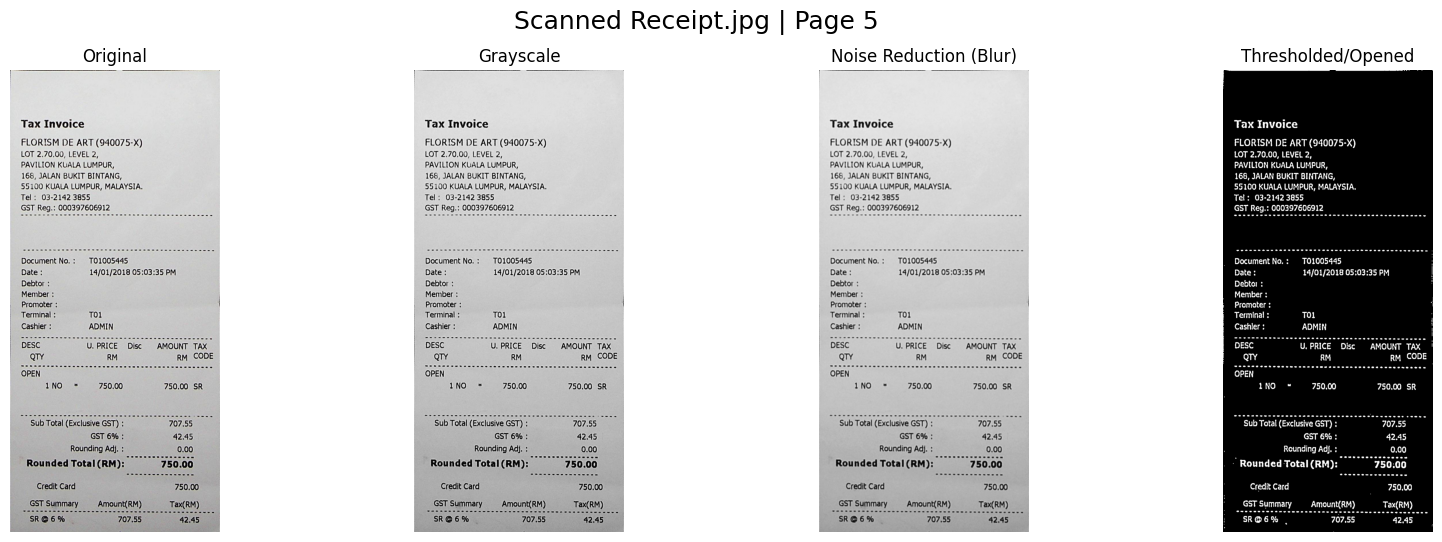

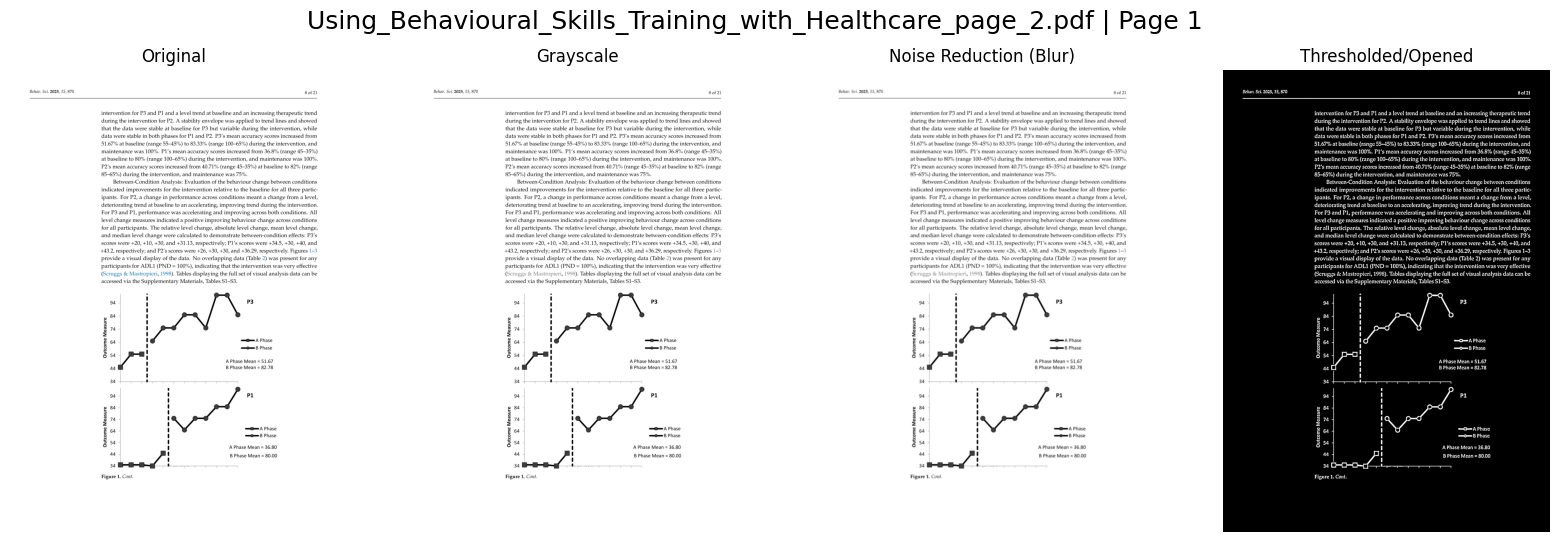

In [11]:
for preview in preview_images:

    original = preview["original"]
    gray = preview["gray"]
    blur = preview["blur"]
    opened = preview["opened"]

    plt.figure(figsize=(20, 6))

    plt.suptitle(
        f"{preview['filename']} | "
        f"Page {preview['page']}",
        fontsize=18
    )

    plt.subplot(1, 4, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    # Grayscale
    plt.subplot(1, 4, 2)
    plt.imshow(gray, cmap="gray")
    plt.title("Grayscale")
    plt.axis("off")

    # Blurred
    plt.subplot(1, 4, 3)
    plt.imshow(blur, cmap='gray')
    plt.title("Noise Reduction (Blur)")
    plt.axis("off")

    # Thresholded/Opened
    plt.subplot(1, 4, 4)
    plt.imshow(opened, cmap="gray")
    plt.title("Thresholded/Opened")
    plt.axis("off")

    plt.show()

## Segmentation and Feature Detection

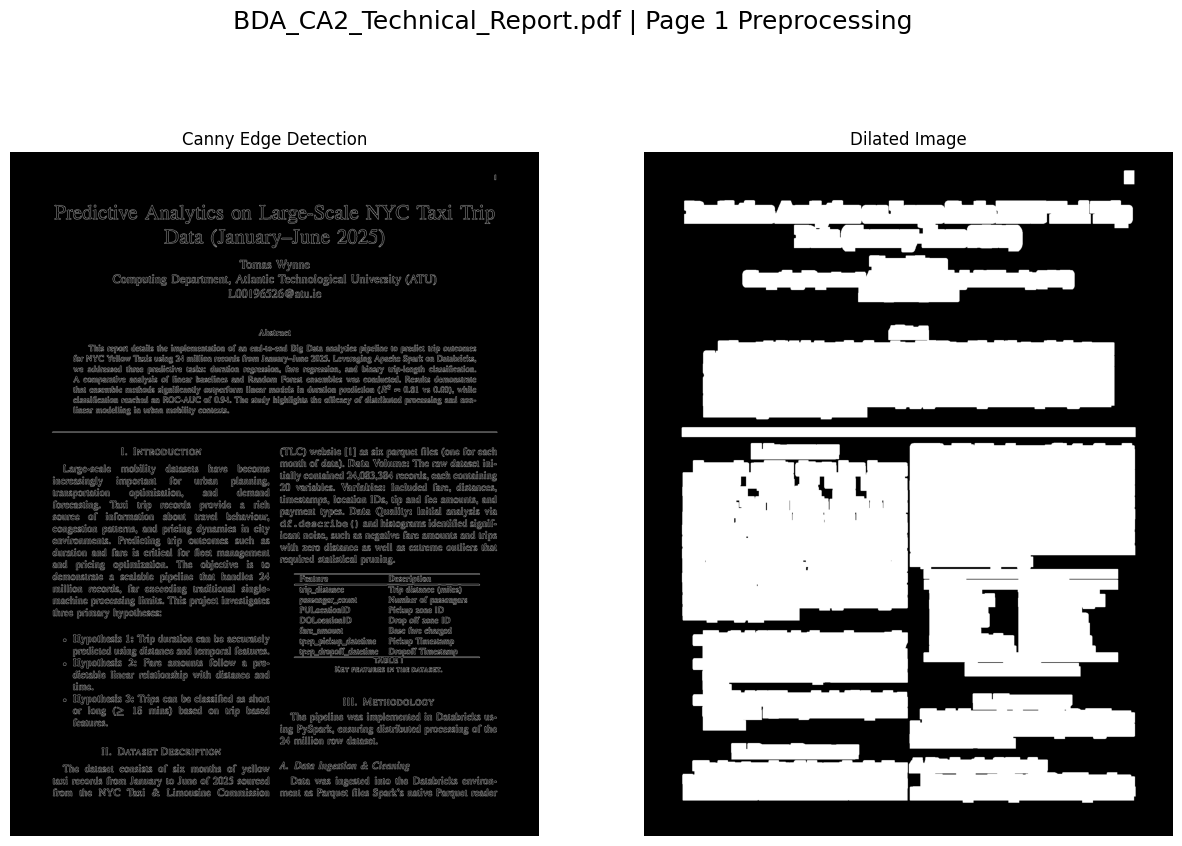


BDA_CA2_Technical_Report.pdf | Page 1
Contours detected: 14
Region Count:
{'Body Text': 9, 'Caption': 3, 'Title': 1}


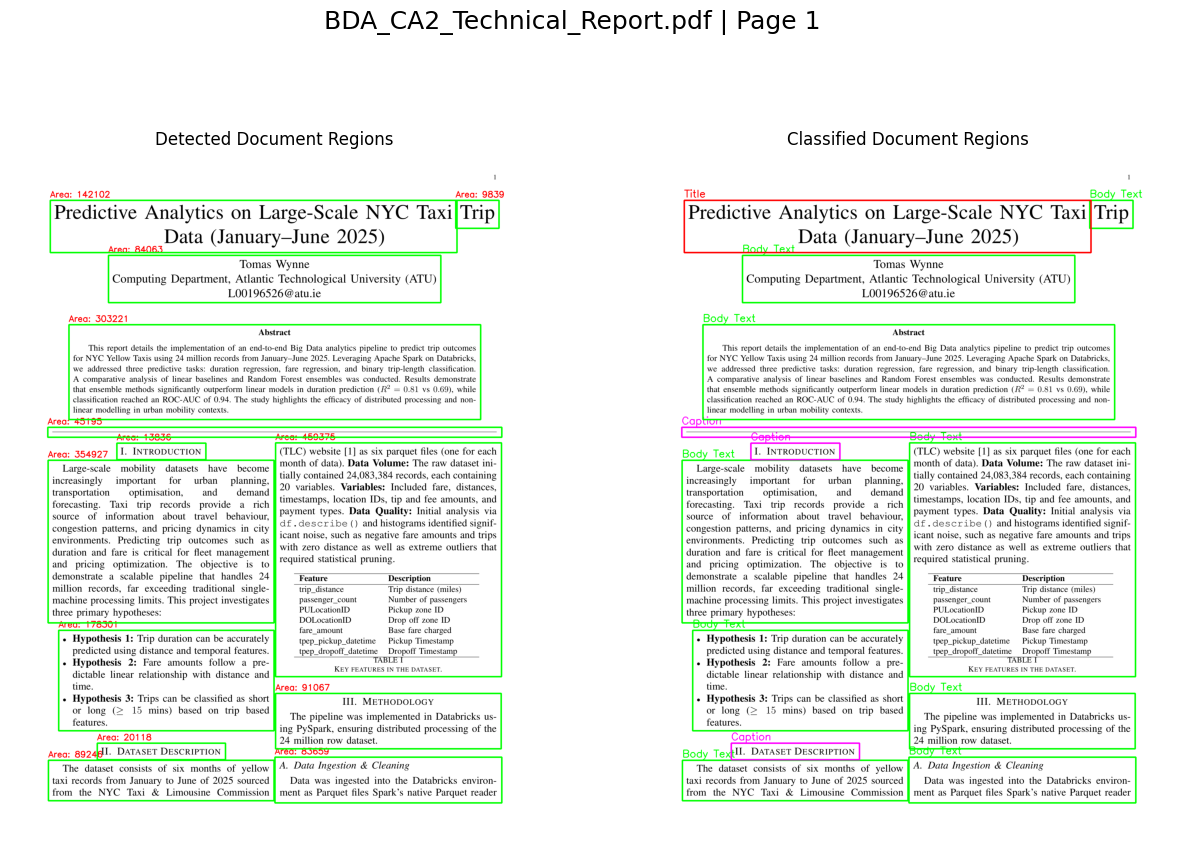

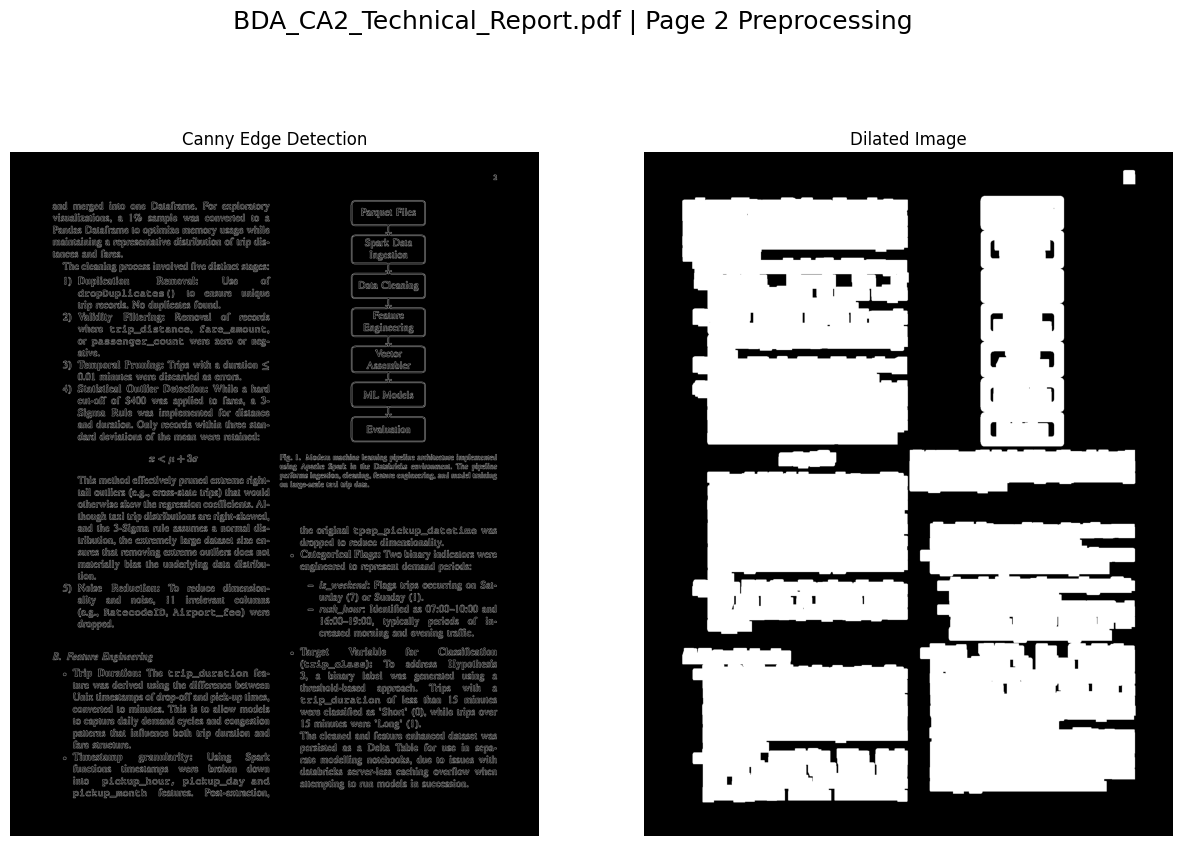


BDA_CA2_Technical_Report.pdf | Page 2
Contours detected: 8
Region Count:
{'Body Text': 6, 'Caption': 1}


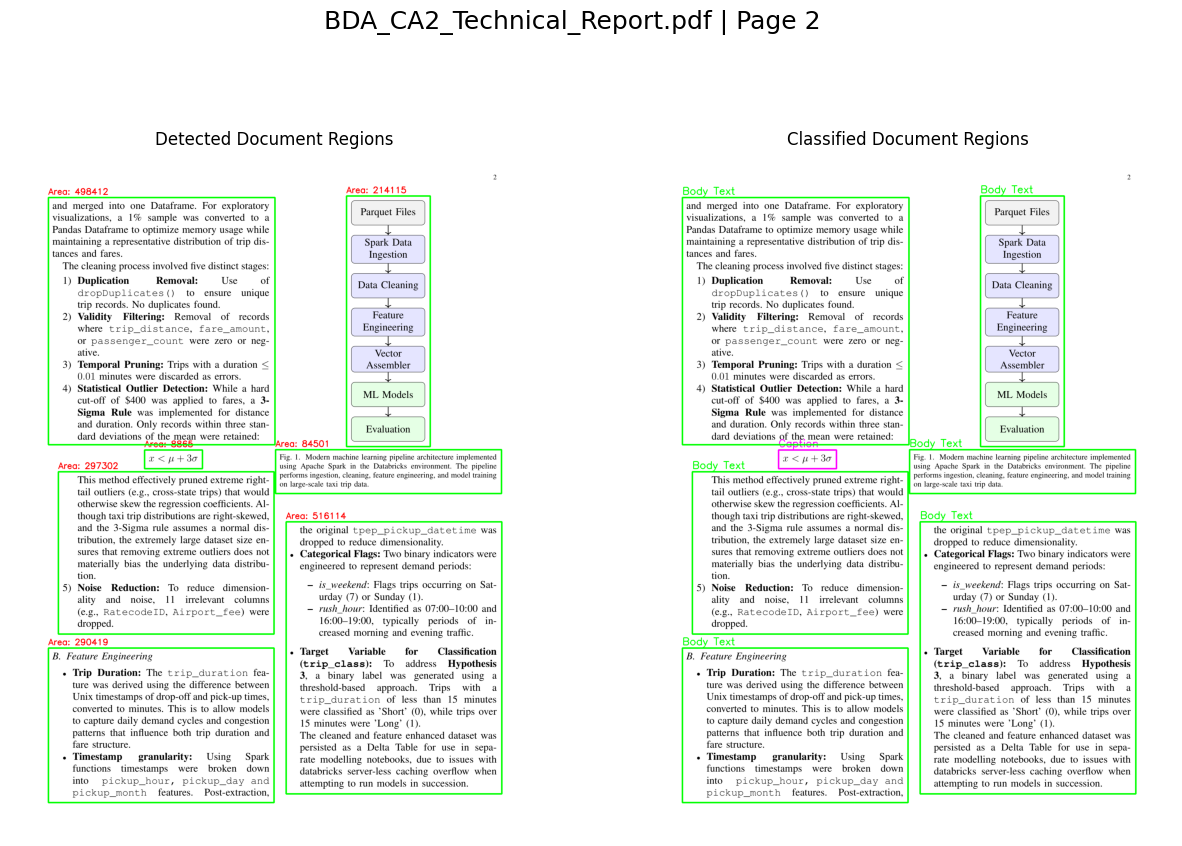

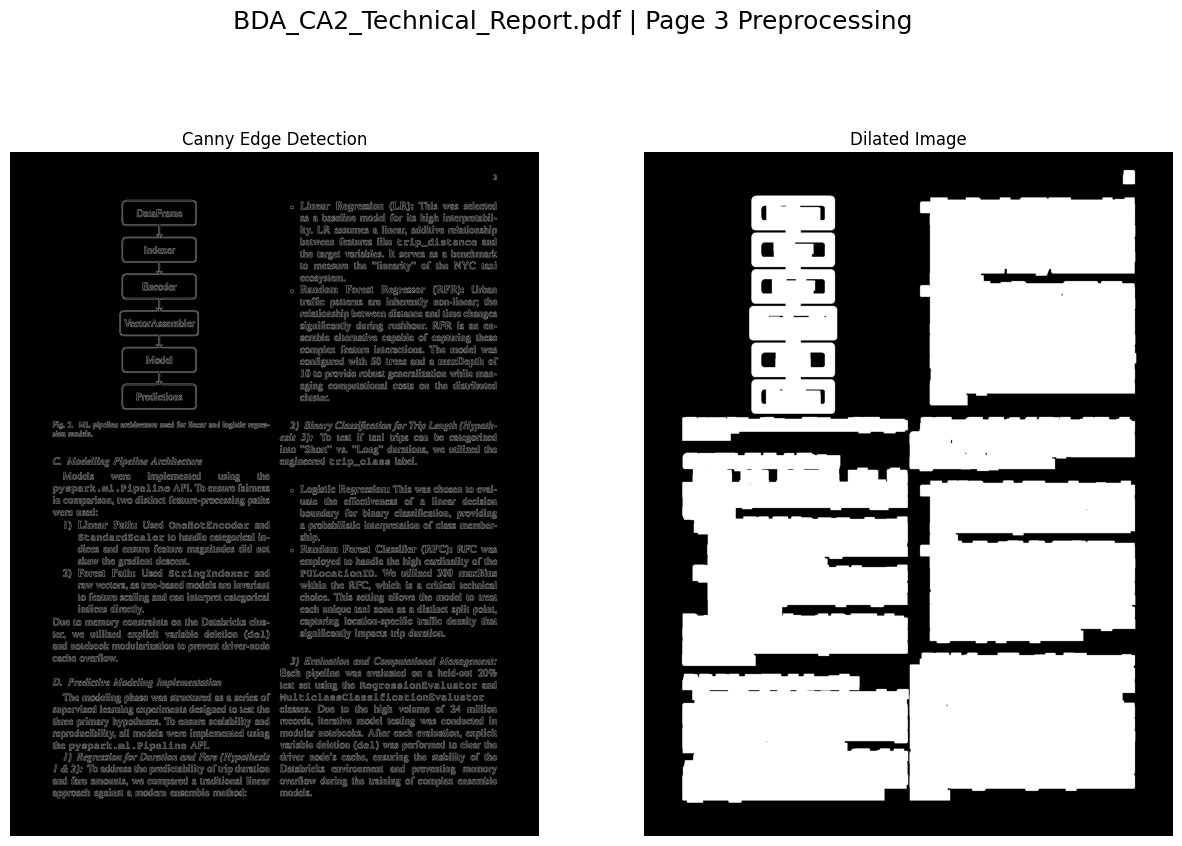


BDA_CA2_Technical_Report.pdf | Page 3
Contours detected: 9
Region Count:
{'Body Text': 6, 'Caption': 1, 'Diagram/Image': 1}


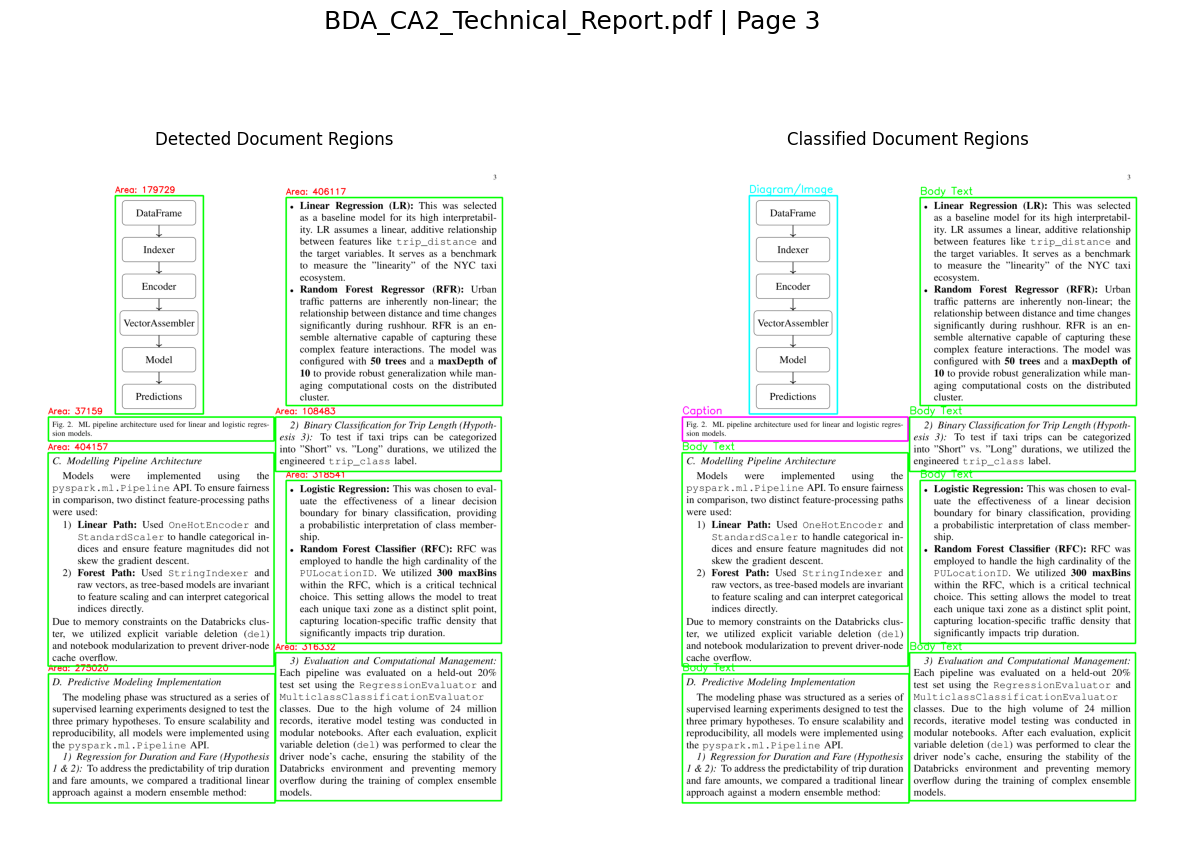

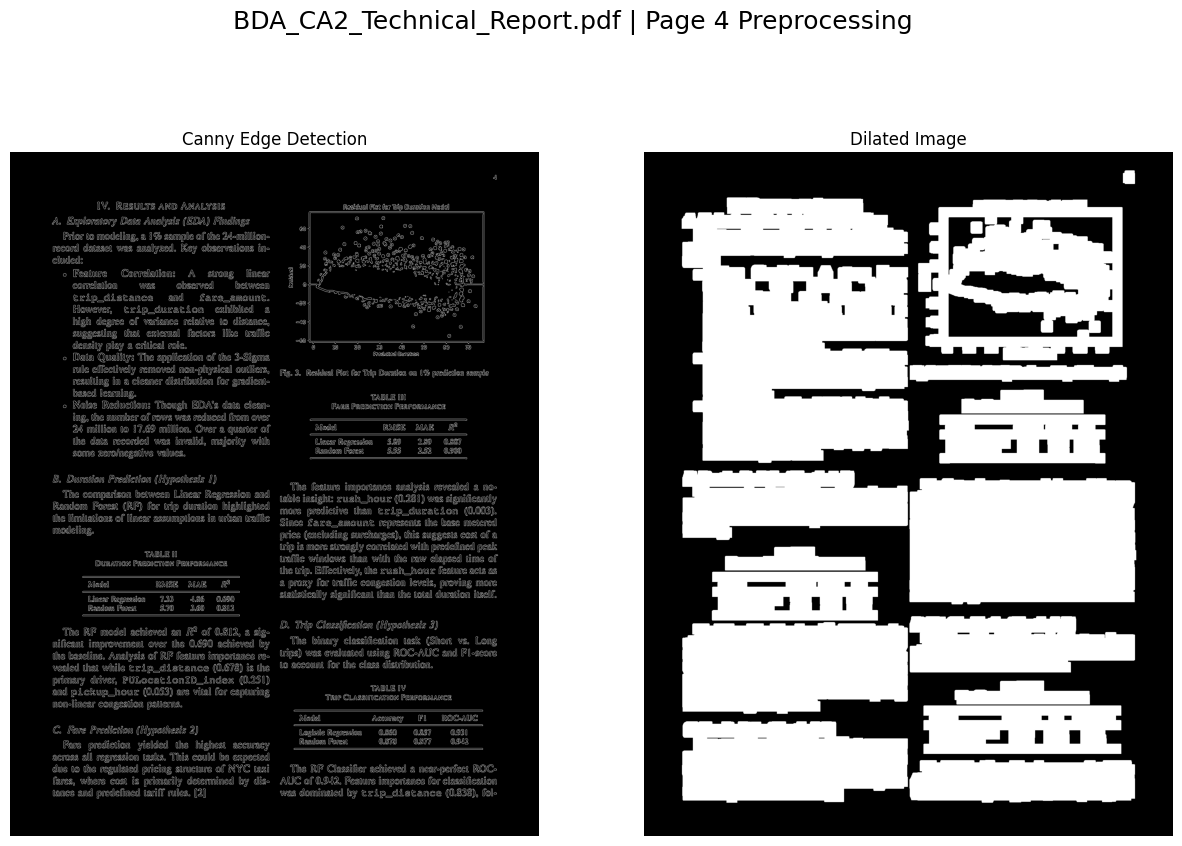


BDA_CA2_Technical_Report.pdf | Page 4
Contours detected: 16
Region Count:
{'Body Text': 10, 'Caption': 4, 'Table': 1}


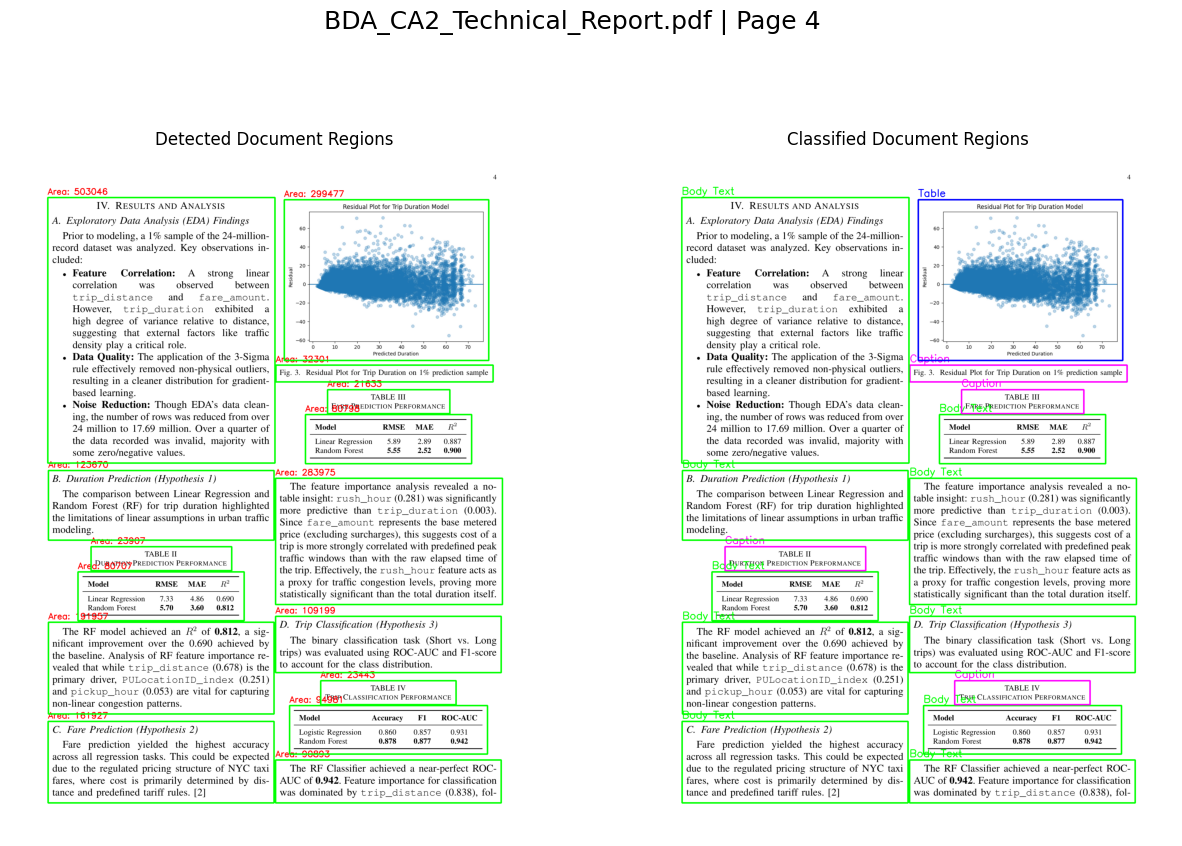

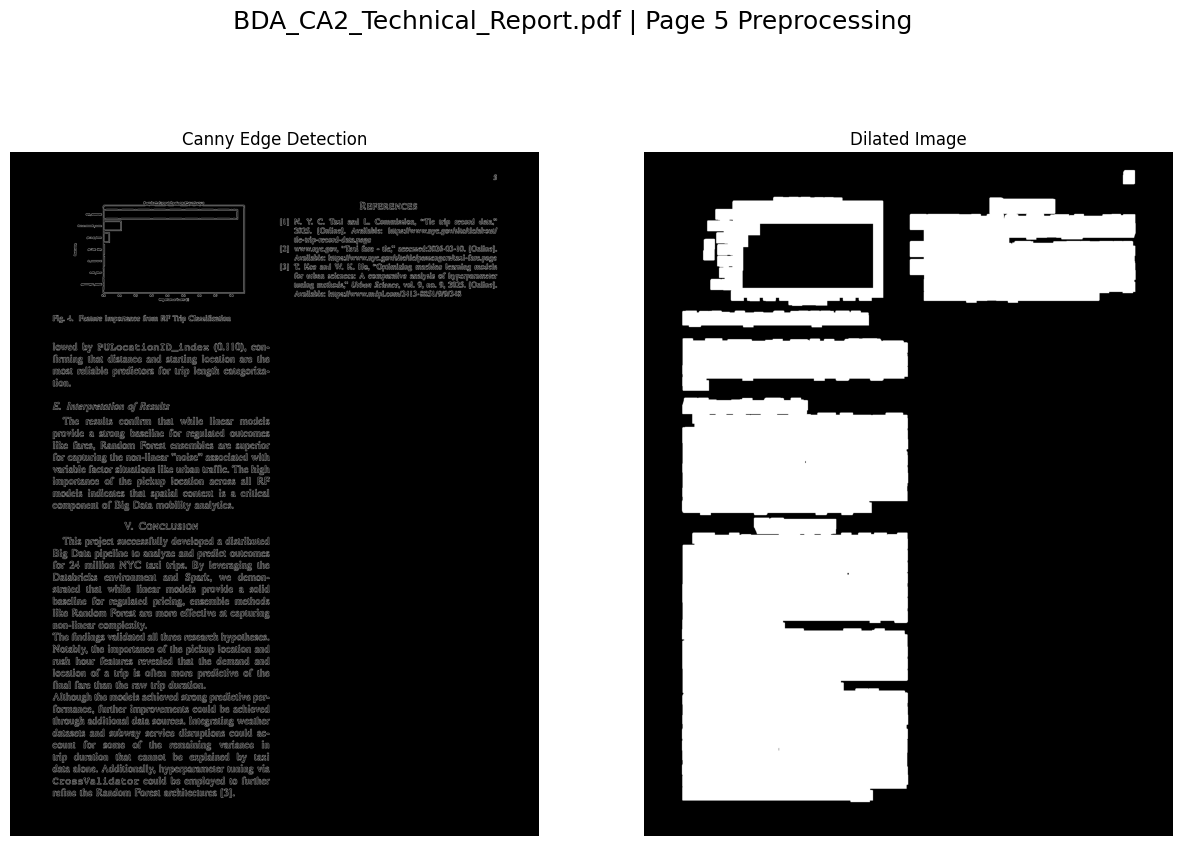


BDA_CA2_Technical_Report.pdf | Page 5
Contours detected: 8
Region Count:
{'Body Text': 5, 'Caption': 1}


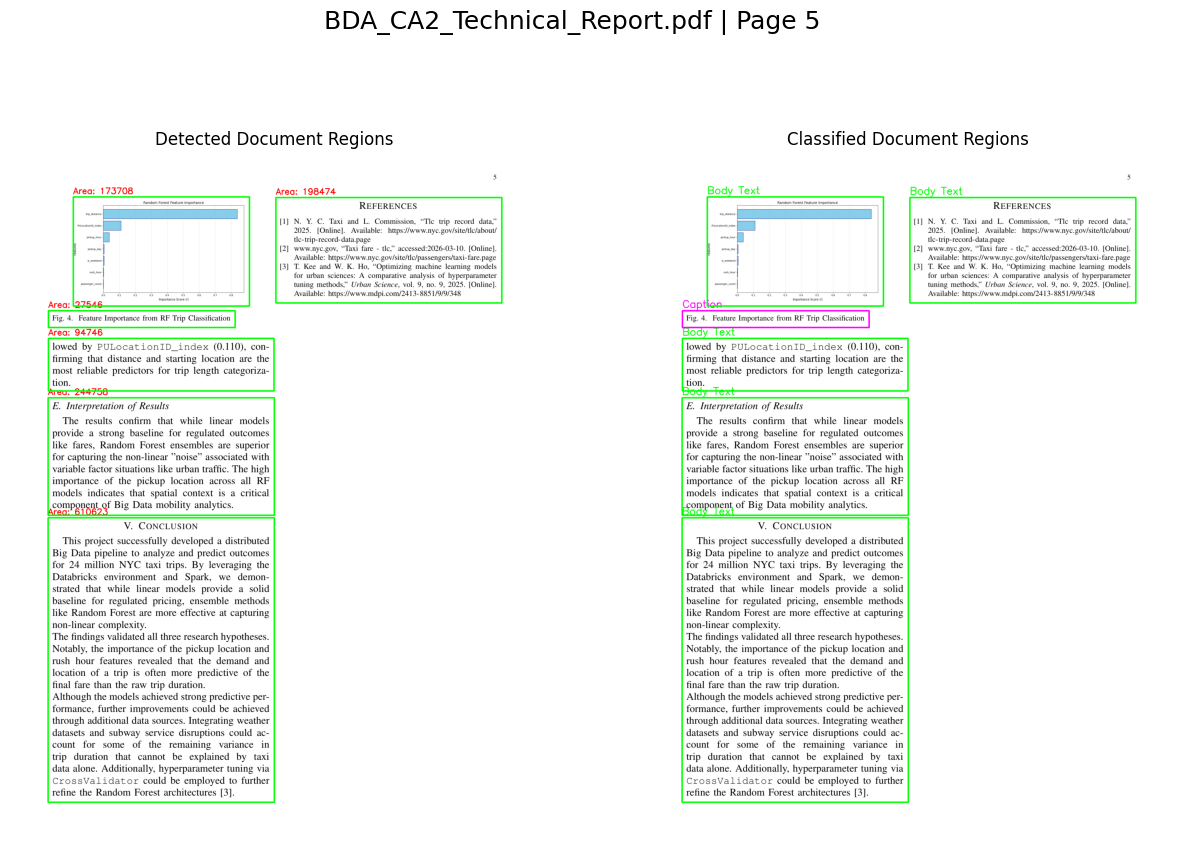

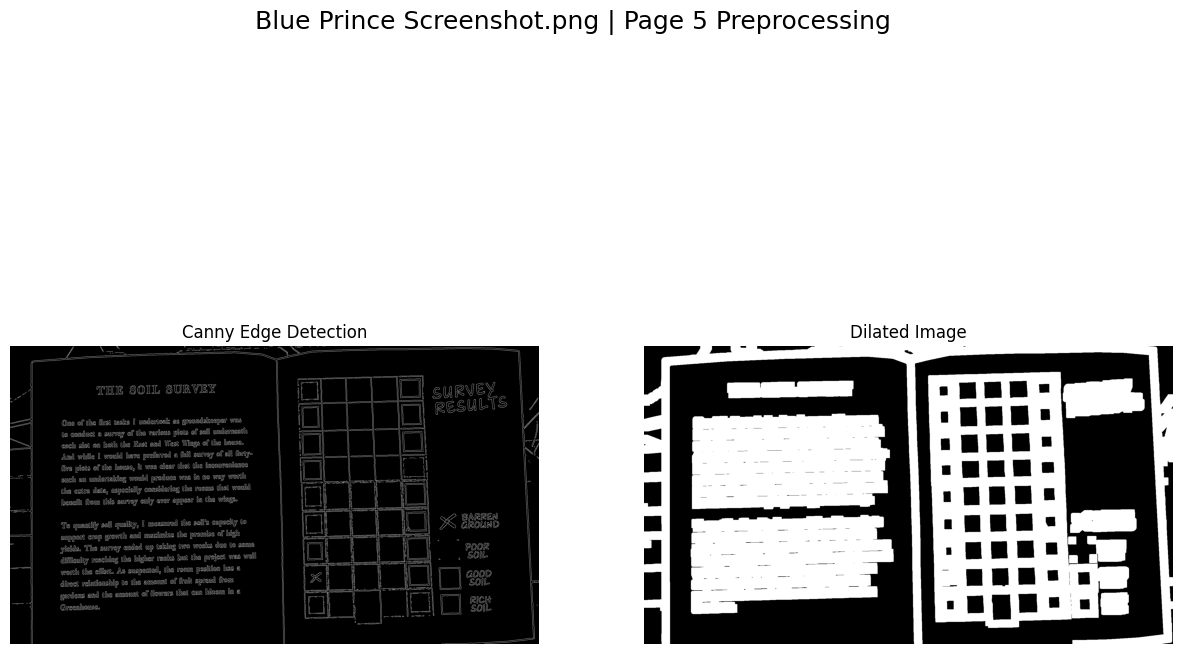


Blue Prince Screenshot.png | Page 5
Contours detected: 11
Region Count:
{'Caption': 3, 'Body Text': 6}


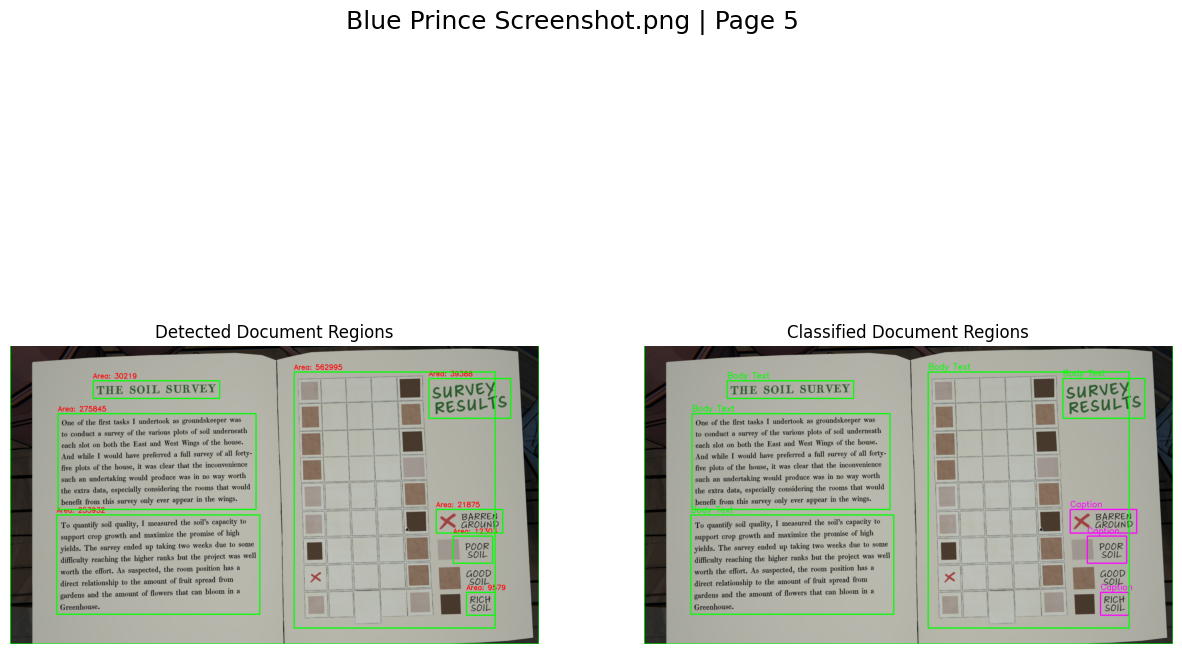

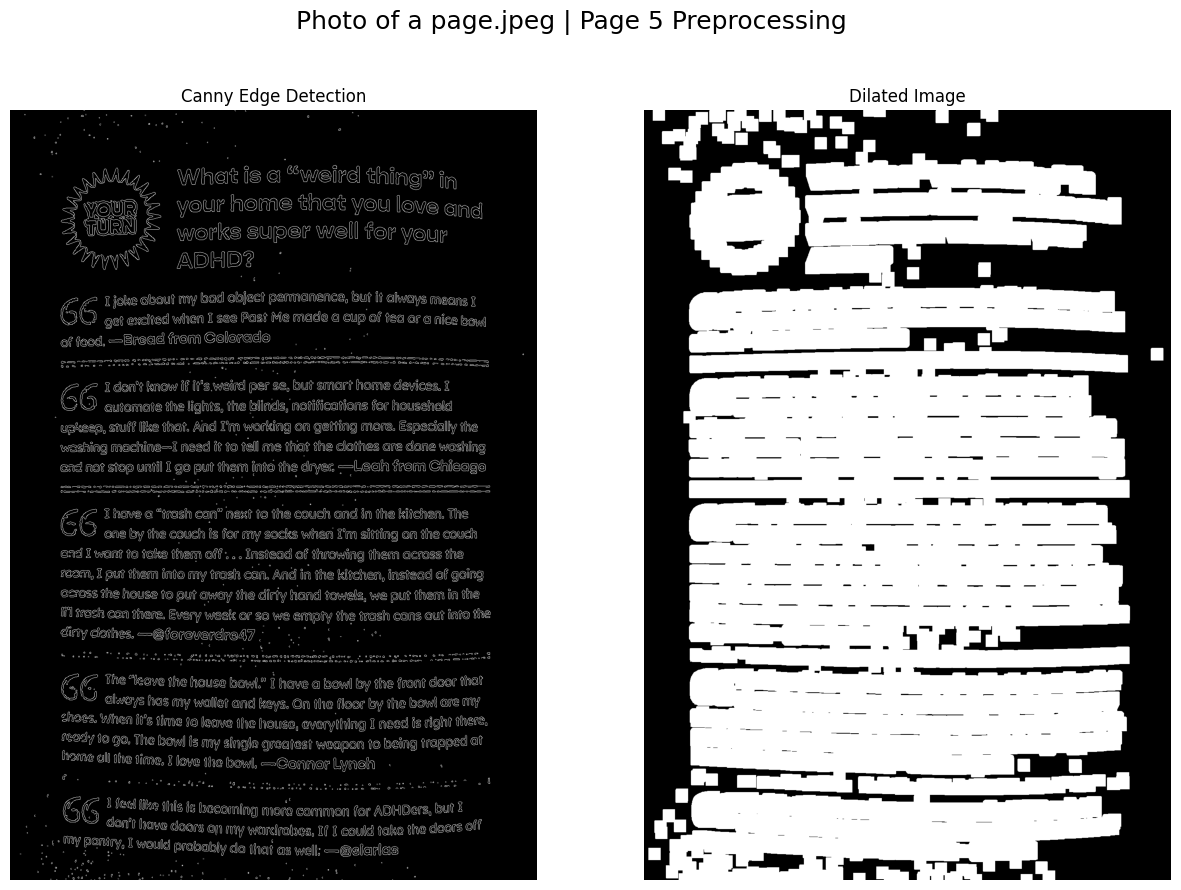


Photo of a page.jpeg | Page 5
Contours detected: 38
Region Count:
{'Body Text': 6}


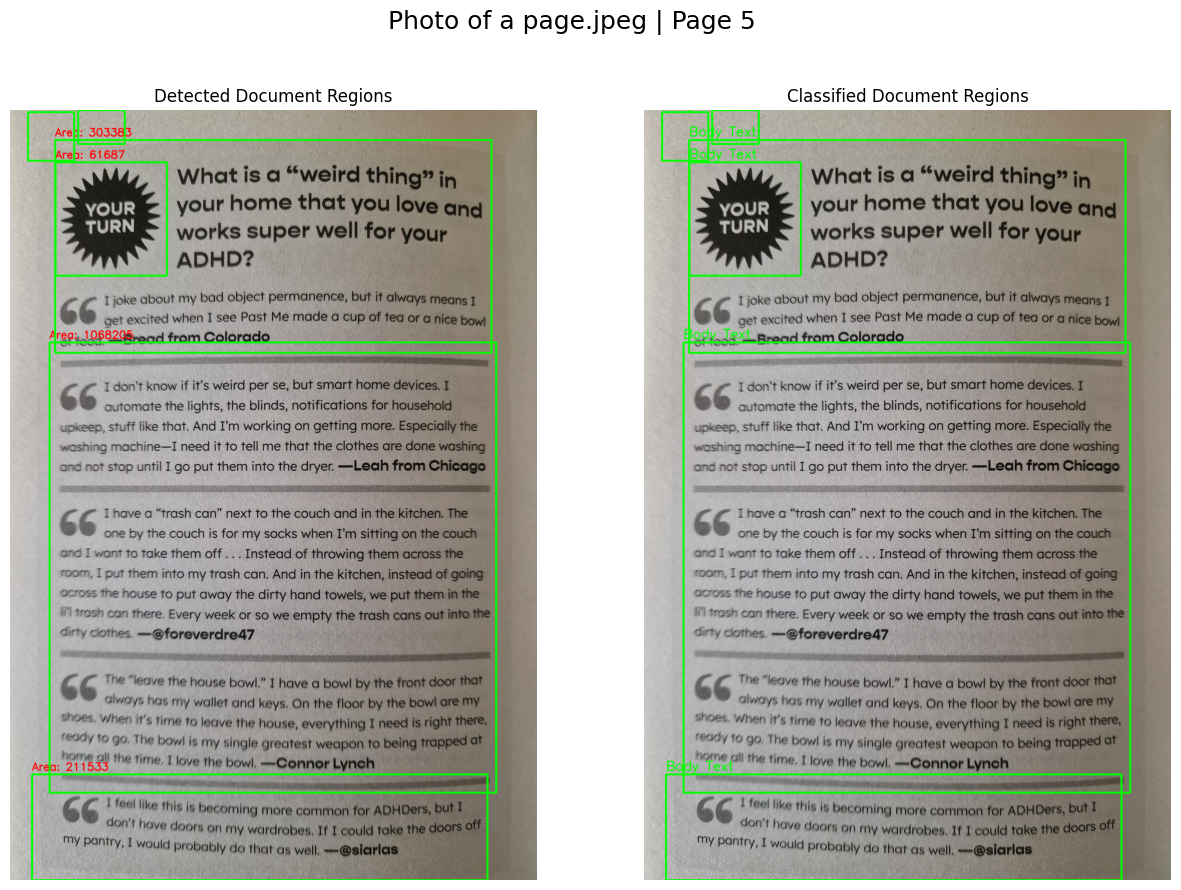

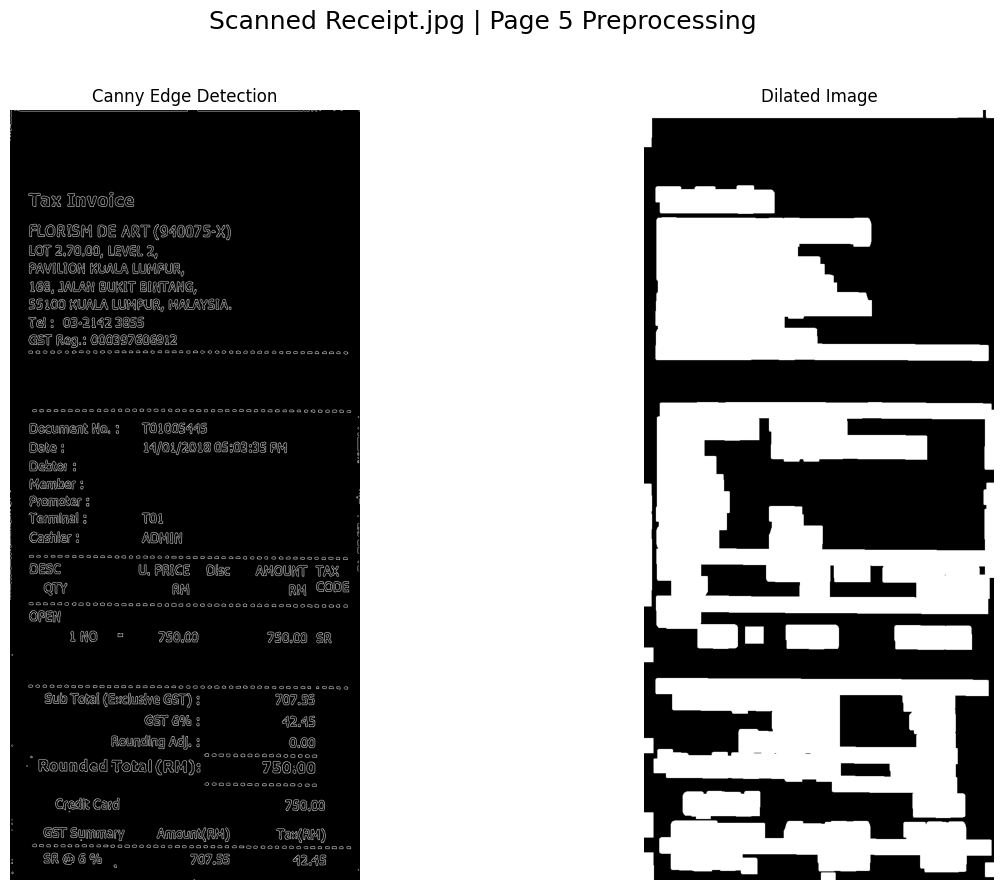


Scanned Receipt.jpg | Page 5
Contours detected: 18
Region Count:
{'Caption': 4, 'Table': 3, 'Body Text': 2}


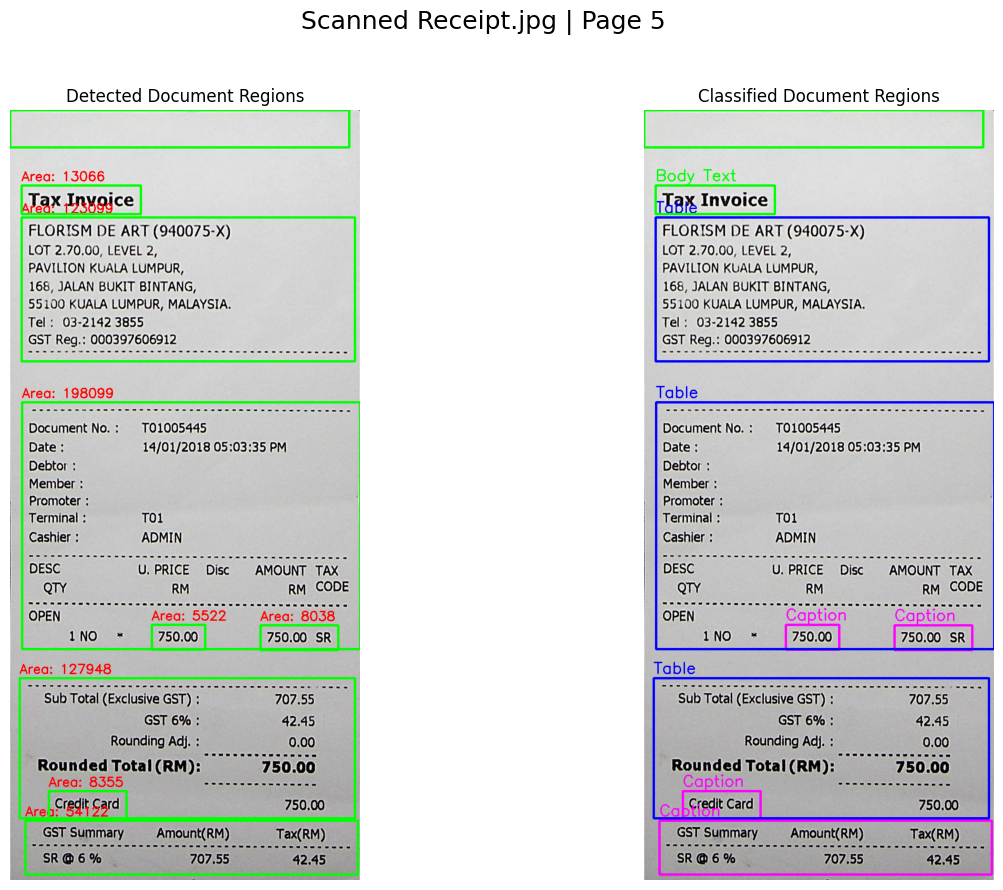

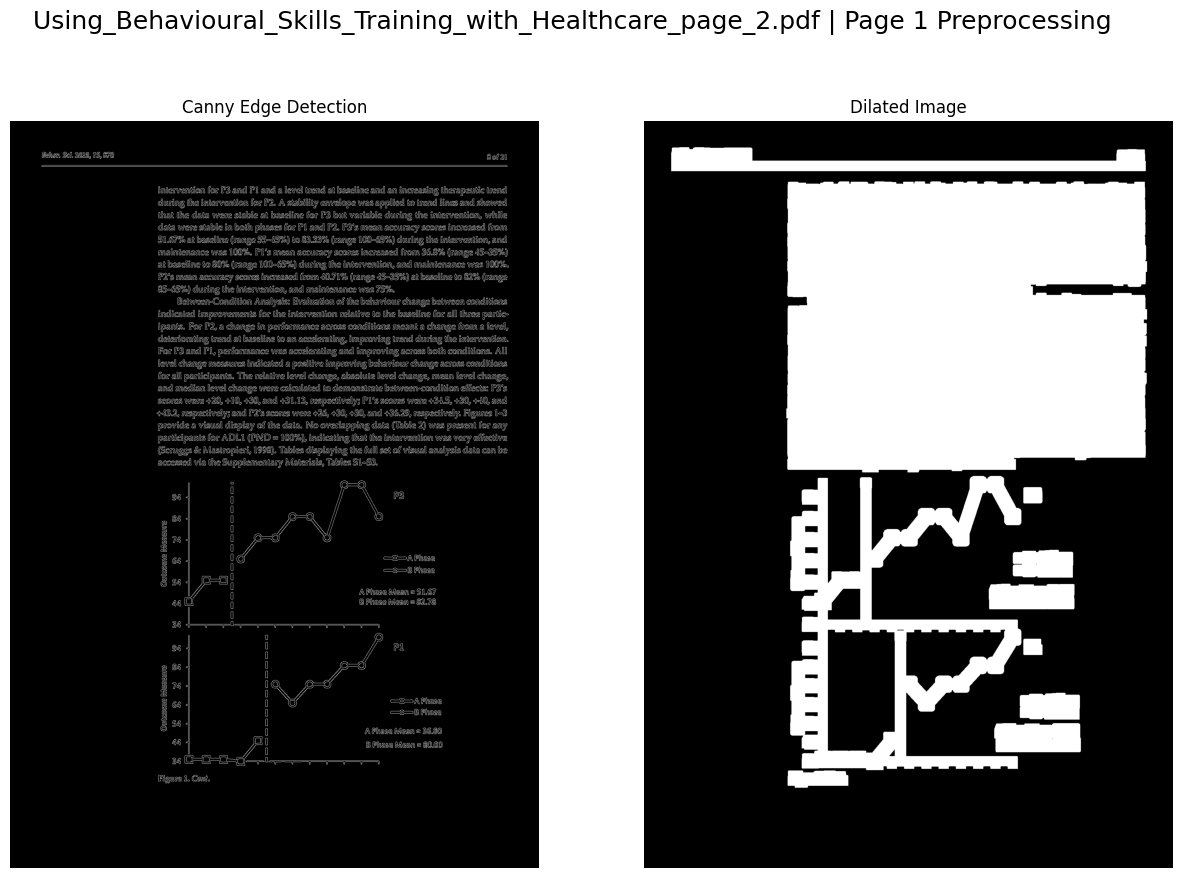


Using_Behavioural_Skills_Training_with_Healthcare_page_2.pdf | Page 1
Contours detected: 10


In [ ]:
all_classified_regions = []

for preview in preview_images:

    original = preview["original"]
    gray = preview["gray"]
    blur = preview["blur"]
    opened = preview["opened"]

    # Edge Detection
    medianval = np.median(original)
    edges = cv2.Canny(opened,threshold1=medianval,threshold2=255) 


    # Dilate the edges to merge blocks together for detection
    kernel = np.ones((15,15), np.uint8)
    dilated = cv2.dilate(edges,kernel,iterations=2)
    

    # Display Canny and Dilated preprocessing
    plt.figure(figsize=(15, 10))
    plt.suptitle(
        f"{preview['filename']} | "
        f"Page {preview['page']} Preprocessing",
        fontsize=18
    )

    plt.subplot(1, 2, 1)
    plt.imshow(edges, cmap="gray")
    plt.title("Canny Edge Detection")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(dilated, cmap="gray")
    plt.title("Dilated Image")
    plt.axis("off")

    plt.show()


    # Contour Detection
    regions = []
    contours, hierarchy = cv2.findContours(
        dilated,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    print(
        f"\n{preview['filename']} "
        f"| Page {preview['page']}"
    )
    print(f"Contours detected: {len(contours)}")

    # Process regions
    regions_image = original.copy()

    for contour in contours:

        # Calculate contour area
        area = cv2.contourArea(contour)

        # Ignore tiny regions
        if area > 5000:

            # Bounding rectangle
            x, y, w, h = cv2.boundingRect(contour)

            # Extract region of interest
            roi = opened[y:y+h, x:x+w]

            # OCR the individual region
            region_text = pytesseract.image_to_string(roi, config=ocr_config)

            # Store region information
            regions.append({
                "x": x,
                "y": y,
                "w": w,
                "h": h,
                "area": area,
                "text": region_text
            })



            # Draw region box
            cv2.rectangle(
                regions_image,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                3
            )


            # Display region size
            cv2.putText(
                regions_image,
                f"Area: {int(area)}",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                .9,
                (255, 0, 0),
                2
            )

    
    classified_regions = []

    for region in regions:

        roi = original[
        region["y"]:region["y"] + region["h"],
        region["x"]:region["x"] + region["w"]
        ]

        label = classify_region(region, roi)

        region["label"] = label

        classified_regions.append(region)

    # Fresh image copy for classified regions
    classified_image = original.copy()

    # Colour Map for classified regions
    colours = {
        "Title": (255, 0, 0),
        "Body Text": (0, 255, 0),
        "Table": (0, 0, 255),
        "Diagram/Image": (0, 255, 255),
        "Caption": (255, 0, 255)
    }

    label_counts = {}

    for region in classified_regions:

        x = region["x"]
        y = region["y"]
        w = region["w"]
        h = region["h"]

        label = region["label"]

        label_counts[label] = label_counts.get(label, 0) + 1

        # Set colour by the label
        colour = colours.get(label, (255, 255, 255))

        roi = original[
            y:y+h,
            x:x+w
        ]

        '''
        # Displays each region individually
        plt.figure(figsize=(6,4))
        plt.imshow(roi)
        plt.title(
            f"{label}\n"
            f"OCR: {region['text'][:80]}"
        )
        plt.axis("off")
        plt.show()
        '''

        # Bounding box for region
        cv2.rectangle(
            classified_image,
            (x, y),
            (x + w, y + h),
            colour,
            3
        )

        # Label the region

        cv2.putText(
        classified_image,
        f"{label}",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.1,
        colour,
        2
    )  
        '''
        # Testing display for region classification, region by region 
        plt.figure(figsize=(18,18))
        plt.imshow(classified_image)
        plt.title("Classified Document Regions")
        plt.axis("off")
        plt.show()
        '''

    print("Region Count:")
    print(label_counts)

    # Store classified results
    all_classified_regions.append({
        "filename": preview["filename"],
        "page": preview["page"],
        "classified_regions": classified_regions,
        "label_counts": label_counts,
        "classified_image": classified_image
    })

# Display Detected and Classified Regions

    plt.figure(figsize=(15,10))
    plt.suptitle(
        f"{preview['filename']} | "
        f"Page {preview['page']}",
        fontsize=18
    )

    plt.subplot(1, 2, 1)
    plt.imshow(regions_image)
    plt.title("Detected Document Regions")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(classified_image)
    plt.title("Classified Document Regions")
    plt.axis("off")

    plt.show()

    # Save classified images
    output_path = os.path.join(
        ANNOTATED_FOLDER,
        f"{preview['filename']}_page_"
        f"{preview['page']}_classified.png"
    )

    cv2.imwrite(output_path,cv2.cvtColor(classified_image, cv2.COLOR_RGB2BGR))

## Display Segmented Regions

In [ ]:
for page_data in all_classified_regions:

    print(f"\n================================================")
    print(
        f"{page_data['filename']} | "
        f"Page {page_data['page']}"
    )
    print(f"\n================================================")

    # Limit number shown
    display_count = 0

    for region in page_data["classified_regions"]:

        # Limit displayed regions to 10
        if display_count >= 10:
            break

        x = region["x"]
        y = region["y"]
        w = region["w"]
        h = region["h"]

        label = region["label"]

        # Get original page image
        original_image = None

        for preview in preview_images:
            if (
                preview["filename"] == page_data["filename"]
                and
                preview["page"] == page_data["page"]
            ):
                
                original_image = preview["original"]
                break

        roi = original_image[
            y:y+h,
            x:x+w
        ]

        plt.figure(figsize=(6,4))
        plt.imshow(roi)
        plt.title(
            f"{label}\n\n"
            f"OCR Preview:\n"
            f"{region['text'][:120]}"
        )
        plt.axis("off")

        plt.show()

# Multi-modal

## Export Multimodal Results

In [ ]:
final_outputs = []

for result, preview in zip(all_results, preview_images):

    multimodal_regions = []

    # Get classified regions
    for region in classified_regions:
        
        multimodal_regions.append({
            "region_type": region["label"],
            "text": region["text"][:200],
            "bounding_box": {
                "x": region["x"],
                "y": region["y"],
                "w": region["w"],
                "h": region["h"]
            }
        })


    final_output = {
        "filename": result["filename"],
        "page": result["page"],
        # NLP
        "keywords": result["top_keywords"],
        "named_entities": result["named_entities"],
        "key_phrases": result["key_phrases"],
        # CV
        "region_counts": label_counts,
        # MULTI-MODAL
        "region_text_mapping": multimodal_regions
    }

    final_outputs.append(final_output)


# EXPORT JSON RESULTS
with open("final_multimodal_results.json", "w", encoding="utf-8") as file:
    json.dump(
        final_outputs,
        file,
        indent=4,
        ensure_ascii=False
    )
print(f"\nResults exported to: {output_json}")

# Final Output

In [ ]:
# ============================================================
# FINAL OUTPUT RESULTS
# ============================================================

for output in final_outputs:

    print("\n================================================")
    print("FINAL DOCUMENT UNDERSTANDING")
    print("================================================")

    print(f"\nFILE: {output['filename']}")
    print(f"PAGE: {output['page']}")

    print("\n--- REGION COUNTS ---")
    print(output["region_counts"])

    print("\n--- KEY PHRASES ---")

    for phrase in output["key_phrases"][:10]:
        print(f"- {phrase}")

    print("\n--- NAMED ENTITIES ---")

    for entity in output["named_entities"][:10]:
        print(
            f"{entity['text']} "
            f"({entity['label']})"
        )

    print("\n--- REGION TEXT MAPPING ---")

    for mapping in output["region_text_mapping"][:5]:

        print(
            f"\n[{mapping['region_type']}]"
        )

        print(mapping["text"][:150])

# References

* Aside from content covered in our labs, the following resources were used.
OpenAI ChatGPT was used to assist with debugging, structuring file intake and document sorting (after pivoting to taking all files in together rather than processing individually) and assisting with establishing the heuristics used to classify regions as body text, tables, captions, etc. https://chatgpt.com/
* https://docs.opencv.org/4.x/d0/d86/tutorial_py_image_arithmetics.html 
* https://www.geeksforgeeks.org/python/python-opencv-morphological-operations/ 
* https://www.geeksforgeeks.org/python/clahe-histogram-eqalization-opencv/ 
* https://docs.opencv.org/4.x/d4/d73/tutorial_py_contours_begin.html
* https://opencv24-python-tutorials.readthedocs.io/en/latest/py_tutorials/py_imgproc/py_morphological_ops/py_morphological_ops.html 